https://www.kaggle.com/datasets/akshaydattatraykhare/diabetes-dataset

## Download dataset

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vntnhnng","key":"6e306af32d405fe52df40851b0e0991d"}'}

### Set Up Kaggle API in Colab


In [ ]:
# Move the kaggle.json file to the directory where the Kaggle API expects it and set appropriate permissions.
import os
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
# Install the Kaggle package if it's not already installed.
!pip install kaggle

### Download the Dataset


In [ ]:
# Download the dataset
!kaggle datasets download -d akshaydattatraykhare/diabetes-dataset

Dataset URL: https://www.kaggle.com/datasets/akshaydattatraykhare/diabetes-dataset
License(s): CC0-1.0
  0% 0.00/8.91k [00:00<?, ?B/s]
100% 8.91k/8.91k [00:00<00:00, 15.0MB/s]


In [ ]:
# Unzip the dataset
!unzip -o diabetes-dataset.zip


Archive:  diabetes-dataset.zip
  inflating: diabetes.csv            


In [ ]:
import sys

assert sys.version_info >= (3, 7)

In [ ]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [ ]:
from pathlib import Path
import pandas as pd

diabetes = pd.read_csv(Path("diabetes.csv"))


## Take a Quick Look at the Data Structure

In [ ]:
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
# extra code – code to save the figures as high-res PNGs

IMAGES_PATH = Path() / "images" / "diabetes_prediction"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

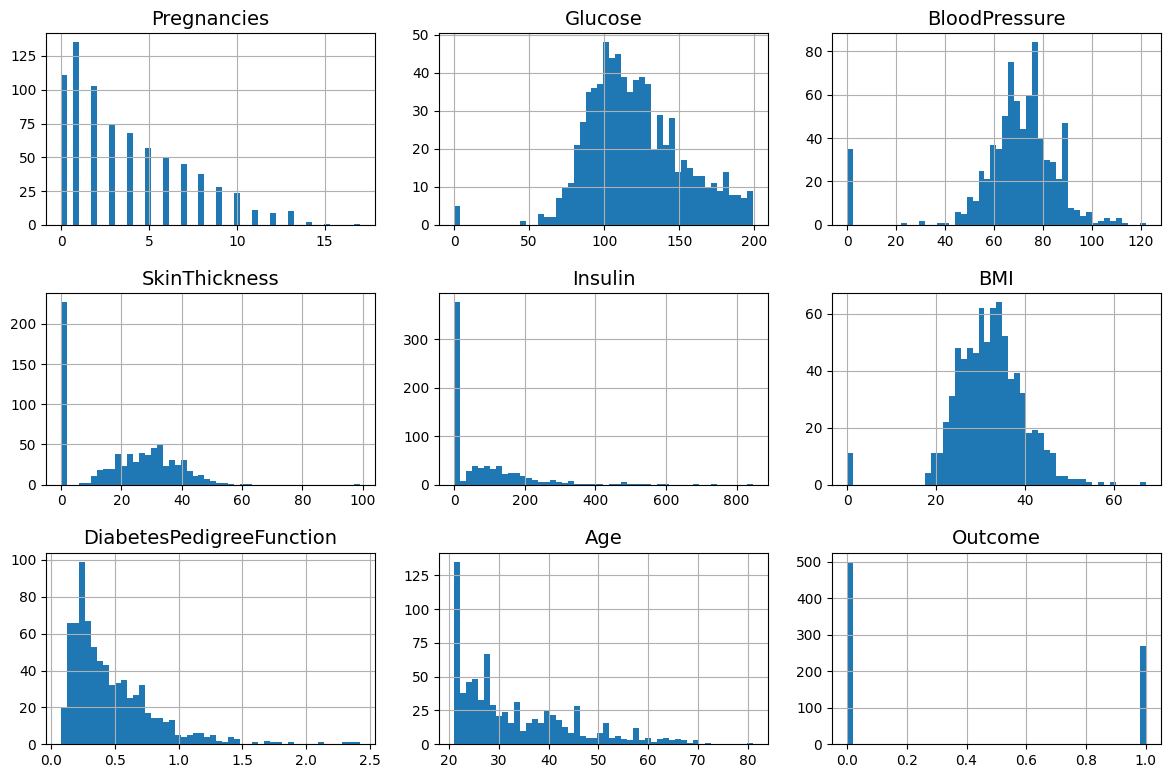

In [ ]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

diabetes.hist(bins=50, figsize=(12, 8))
save_fig("attribute_histogram_plots")  # extra code
plt.show()

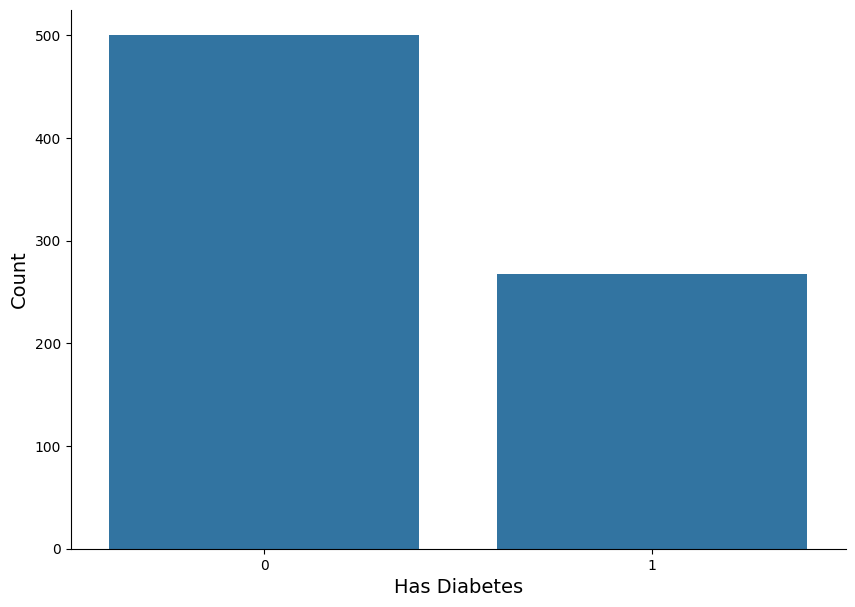

In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn
# Plotting the Outcomes based on the number of dataset entries
plt.figure(figsize=(10,7))
seaborn.countplot(x='Outcome', data=diabetes)

# Removing the unwanted spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Headings
plt.xlabel('Has Diabetes')
plt.ylabel('Count')

plt.show()

# Discover and Visualize the Data to Gain Insights

## Looking for Correlations

In [ ]:
corr_matrix = diabetes.corr(numeric_only=True)

In [ ]:
corr_matrix["Outcome"].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

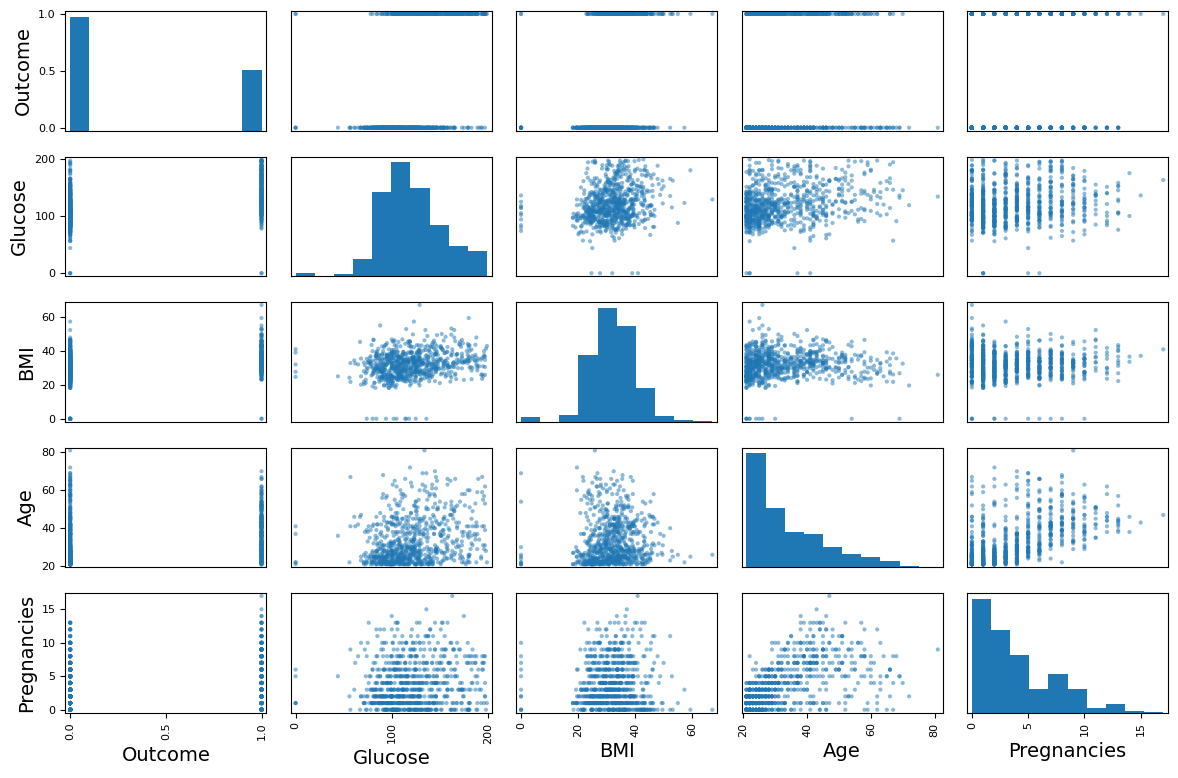

In [ ]:
from pandas.plotting import scatter_matrix

attributes = ["Outcome", "Glucose", "BMI", "Age", "Pregnancies"]
scatter_matrix(diabetes[attributes], figsize=(12, 8))
save_fig("scatter_matrix_plot")  # extra code
plt.show()

# Prepare the Data for Machine Learning Algorithms

In [ ]:
diabetes.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## Data Cleaning

## Transformation Pipelines

In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, ShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Specify the feature types
num_features = ["Glucose", "BMI", "Age", "DiabetesPedigreeFunction"]
pregnancies_feature = ["Pregnancies"]
other_features = ["Insulin", "SkinThickness", "BloodPressure"]

# Preprocessing for numerical data
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler()),
])

# Preprocessing for 'Pregnancies' feature (no transformation)
pregnancies_pipeline = Pipeline([
    ('pass', 'passthrough')
])

# Preprocessing for other features
other_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('scaler', StandardScaler()),
])

# Combine preprocessing steps
preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("pregnancies", pregnancies_pipeline, pregnancies_feature),
    ("other", other_pipeline, other_features)
])

smote_processing = Pipeline([
    ("preprocessing", preprocessing),
    ("smote", SMOTE(random_state=42)),
])

# Full pipeline with SMOTE and a classifier
def create_pipeline_with_smote(classifier):
    return Pipeline([
        ("preprocessing", preprocessing),
        ("smote", SMOTE(random_state=42)),
        ("classifier", classifier),
    ])


In [ ]:
!pip install tensorflow pandas numpy scikit-learn


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, LeakyReLU, BatchNormalization, Reshape, Flatten
from tensorflow.keras.models import Model, Sequential

# Function to train GAN
def train_gan(X_train, latent_dim=100, epochs=1000000, batch_size=64):
    def build_generator(latent_dim, n_features):
        model = Sequential()
        model.add(Dense(128, input_dim=latent_dim))
        model.add(LeakyReLU(alpha=0.2))
        model.add(Dense(256))
        model.add(LeakyReLU(alpha=0.2))
        model.add(Dense(n_features, activation='linear'))
        return model

    def build_discriminator(n_features):
        model = Sequential()
        model.add(Dense(256, input_dim=n_features))
        model.add(LeakyReLU(alpha=0.2))
        model.add(Dense(128))
        model.add(LeakyReLU(alpha=0.2))
        model.add(Dense(1, activation='sigmoid'))
        return model

    n_features = X_train.shape[1]
    generator = build_generator(latent_dim, n_features)
    discriminator = build_discriminator(n_features)

    discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    discriminator.trainable = False
    gan = Sequential([generator, discriminator])
    gan.compile(optimizer='adam', loss='binary_crossentropy')

    half_batch = batch_size // 2
    for epoch in range(epochs):
        noise = np.random.normal(0, 1, (half_batch, latent_dim))
        gen_data = generator.predict(noise)

        idx = np.random.randint(0, X_train.shape[0], half_batch)
        real_data = X_train[idx]

        d_loss_real = discriminator.train_on_batch(real_data, np.ones((half_batch, 1)))
        d_loss_fake = discriminator.train_on_batch(gen_data, np.zeros((half_batch, 1)))
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        g_loss = gan.train_on_batch(noise, np.ones((batch_size, 1)))

        if epoch % 1000 == 0:
            print(f"{epoch} [D loss: {d_loss[0]} | D accuracy: {100*d_loss[1]}] [G loss: {g_loss}]")

    return generator

In [ ]:
data = diabetes.drop("Outcome", axis=1)
labels = diabetes["Outcome"].copy()

In [ ]:
# Apply preprocessing and SMOTE
X_smote, y_smote = smote_processing.fit_resample(data, labels)

# Train GAN
generator = train_gan(X_smote)


Streaming output truncated to the last 5000 lines.
1/1 [==============================] - 0s 25ms/step
153000 [D loss: 0.15107442811131477 | D accuracy: 92.1875] [G loss: 6.181914806365967]
1/1 [==============================] - 0s 26ms/step
154000 [D loss: 0.21363810449838638 | D accuracy: 95.3125] [G loss: 5.961996078491211]
1/1 [==============================] - 0s 30ms/step
155000 [D loss: 0.08433593437075615 | D accuracy: 98.4375] [G loss: 4.673273086547852]
1/1 [==============================] - 0s 37ms/step
156000 [D loss: 0.22686021775007248 | D accuracy: 87.5] [G loss: 5.252188682556152]
1/1 [==============================] - 0s 20ms/step
157000 [D loss: 0.12895498797297478 | D accuracy: 93.75] [G loss: 7.835745334625244]
1/1 [==============================] - 0s 25ms/step


In [ ]:
# Function to apply pipeline, train GAN, and generate synthetic data
def generate_dataset(data, labels, result_size=1000):

    # Generate synthetic data
    latent_dim = 100
    noise = np.random.normal(0, 1, (result_size, latent_dim))
    synthetic_data = generator.predict(noise)
    synthetic_labels = np.random.choice(y_smote, size=synthetic_data.shape[0])

    # Combine original and synthetic data
    combined_data = np.vstack([X_smote, synthetic_data])
    combined_labels = np.hstack([y_smote, synthetic_labels])

    # Convert back to DataFrame for combined data and labels
    combined_df = pd.DataFrame(combined_data, columns=data.columns)
    combined_df['Outcome'] = combined_labels


    return combined_df

In [ ]:
diabetes = generate_dataset(data, labels, 10000)

In [ ]:
diabetes.info()

In [ ]:
print(diabetes.describe())


In [ ]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn
# Plotting the Outcomes based on the number of dataset entries
plt.figure(figsize=(10,7))
seaborn.countplot(x='Outcome', data=diabetes)

# Removing the unwanted spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Headings
plt.xlabel('Has Diabetes')
plt.ylabel('Count')

plt.show()

## Create a Test Set

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(diabetes, test_size=0.2, stratify=diabetes["Outcome"], random_state=42)

In [ ]:
diabetes = strat_train_set.drop("Outcome", axis=1)
diabetes_labels = strat_train_set["Outcome"].copy()

In [ ]:
diabetes_labels.isnull().sum()


In [ ]:
print(diabetes.describe())


In [ ]:

print(diabetes_labels.describe())


## Select and Train a Model

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

log_reg = make_pipeline(preprocessing, LogisticRegression())
log_reg.fit(diabetes, diabetes_labels)

In [ ]:
diabetes_predictions = log_reg.predict(diabetes)
y_pred = log_reg.predict(diabetes)
y_pred_proba = log_reg.predict_proba(diabetes)[:, 1]  # Probability estimates for the positive class

# Evaluate the model
accuracy = accuracy_score(diabetes_labels, y_pred)
precision = precision_score(diabetes_labels, y_pred)
recall = recall_score(diabetes_labels, y_pred)
f1 = f1_score(diabetes_labels, y_pred)
roc_auc = roc_auc_score(diabetes_labels, y_pred_proba)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC Score:", roc_auc)

cm = confusion_matrix(diabetes_labels, y_pred)
print("Confusion Matrix:\n", cm)

print("Classification Report:\n", classification_report(diabetes_labels, y_pred))


In [ ]:
diabetes_predictions[:5]

In [ ]:
diabetes_labels.iloc[:5].values

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_clf = make_pipeline(preprocessing, SGDClassifier())
sgd_clf.fit(diabetes, diabetes_labels)


In [ ]:
y_pred = sgd_clf.predict(diabetes)

# Evaluate the model
accuracy = accuracy_score(diabetes_labels, y_pred)
precision = precision_score(diabetes_labels, y_pred)
recall = recall_score(diabetes_labels, y_pred)
f1 = f1_score(diabetes_labels, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

cm = confusion_matrix(diabetes_labels, y_pred)
print("Confusion Matrix:\n", cm)

print("Classification Report:\n", classification_report(diabetes_labels, y_pred))


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

def random_search_cv_find_best_model(X, y):
    models = {
        'logistic_regression': {
            'model': LogisticRegression(solver='lbfgs', max_iter=10000),
            'parameters': {
                'classifier__C': [0.1, 1, 10]
            }
        },
        'decision_tree': {
            'model': DecisionTreeClassifier(splitter='best'),
            'parameters': {
                'classifier__criterion': ['gini', 'entropy'],
                'classifier__max_depth': [5, 10]
            }
        },
        'random_forest': {
            'model': RandomForestClassifier(criterion='gini', random_state=42),
            'parameters': {
                'classifier__n_estimators': [10, 50, 100, 200],
                'classifier__max_features': [2, 3, 4]
            }
        },
        'svm': {
            'model': SVC(gamma='auto', probability=True),
            'parameters': {
                'classifier__C': [0.1, 1, 10],
                'classifier__kernel': ['rbf', 'linear']
            }
        },
        'knn': {
            'model': KNeighborsClassifier(),
            'parameters': {
                'classifier__n_neighbors': [3, 5, 10, 20],
                'classifier__weights': ['uniform', 'distance']
            }
        }
    }

    scores = []
    cv_shuffle = ShuffleSplit(n_splits=5, test_size=0.20, random_state=42)
    best_estimators = {}

    for model_name, model_params in models.items():
        pipeline = create_pipeline_with_smote(model_params['model'])
        rs = RandomizedSearchCV(pipeline, model_params['parameters'], cv=cv_shuffle, return_train_score=False, n_iter=20, random_state=42)
        rs.fit(X, y)
        best_estimators[model_name] = rs.best_estimator_
        scores.append({
            'model': model_name,
            'best_parameters': rs.best_params_,
            'score': rs.best_score_
        })

    return pd.DataFrame(scores, columns=['model', 'best_parameters', 'score']), best_estimators

best_models_df, best_estimators = random_search_cv_find_best_model(diabetes, diabetes_labels)
print(best_models_df)

# Extract feature importances from the best random forest model
best_rf = best_estimators['random_forest']
feature_importances = best_rf.named_steps['classifier'].feature_importances_

# Combine numerical and categorical feature names
# feature_names = num_features + list(best_rf.named_steps['preprocessing'].transformers_[1][1]['onehot'].get_feature_names_out())
feature_names = num_features + pregnancies_feature + other_features;
# Display feature importances
feature_importances_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
feature_importances_df = feature_importances_df.sort_values(by='importance', ascending=False)
print(feature_importances_df)


## Evaluate The System on the Test Set

In [ ]:
from sklearn.metrics import mean_squared_error

X_test = strat_test_set.drop("Outcome", axis=1)
y_test = strat_test_set["Outcome"].copy()
best_model = best_estimators['svm']
final_predictions = best_model.predict(X_test)

## Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error, r2_score, roc_auc_score, roc_curve, classification_report, auc
confusion_matrix_result = confusion_matrix(y_test, final_predictions)
classification_report_result = classification_report(y_test, final_predictions)
acuracy_score_result = accuracy_score(y_test, final_predictions)
print("Confusion Matrix:")
print(confusion_matrix_result)
print("\nClassification Report:")
print(classification_report_result)
print("\nAccuracy Score:")
print(acuracy_score_result)



## Model persistence using joblib

Save the final model:

In [ ]:
import joblib

joblib.dump(best_model, "diabetes_prediction_model.pkl")

Now you can deploy this model to production. For example, the following code could be a script that would run in production:

In [ ]:
import joblib

# extra code – excluded for conciseness
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel

final_model_reloaded = joblib.load("diabetes_prediction_model.pkl")

new_data = diabetes.iloc[:5]  # pretend these are new diabetes
predictions = final_model_reloaded.predict(new_data)

In [ ]:
predictions

Compare against the actual values:

In [ ]:
diabetes_labels.iloc[:5].values